In [1]:
# %%
# Importação das bibliotecas necessárias
# Manipulação de dados
import os
import glob
import ctypes
import site
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import pywt  # Biblioteca para transformacoes wavelet
import keras_tuner as kt
# Pré-processamento
from sklearn.preprocessing import MinMaxScaler

import keras

from keras import backend as K


# Componentes do modelo Seq2Seq com Atenção
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dropout, Dense, Concatenate, TimeDistributed, Attention
from tensorflow.keras.layers import (
    Conv1D,
    BatchNormalization,
    Activation,
    Add,
    LayerNormalization,
    Flatten,
    Reshape,
    SpatialDropout1D,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Métricas de avaliação
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Otimizar alocacao de memoria GPU - reduz fragmentacao
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'  # Reduce TensorFlow logging verbosity

# Garante runtime de GPU no Arch Linux (cuSOLVER e libs CUDA via wheel)
def configure_tensorflow_gpu_runtime():
    """Configura paths CUDA do venv e pre-carrega bibliotecas antes do import do TensorFlow."""
    current_ld = os.environ.get('LD_LIBRARY_PATH', '')
    candidate_dirs = []

    for sp in site.getsitepackages():
        candidate_dirs.extend(glob.glob(os.path.join(sp, 'nvidia', '*', 'lib')))

    if 'VIRTUAL_ENV' in os.environ:
        candidate_dirs.extend(
            glob.glob(
                os.path.join(
                    os.environ['VIRTUAL_ENV'],
                    'lib',
                    'python*',
                    'site-packages',
                    'nvidia',
                    '*',
                    'lib',
                )
            )
        )

    valid_dirs = []
    for lib_dir in candidate_dirs:
        if os.path.isdir(lib_dir) and lib_dir not in valid_dirs:
            valid_dirs.append(lib_dir)

    if valid_dirs:
        merged = ':'.join(valid_dirs)
        os.environ['LD_LIBRARY_PATH'] = f"{merged}:{current_ld}" if current_ld else merged

        # Pre-carrega libs CUDA para evitar falha de resolucao dinamica no kernel do VS Code
        preload_libs = [
            'libcudart.so.12',
            'libcublas.so.12',
            'libcudnn.so.9',
            'libcusolver.so.11',
        ]
        for lib_name in preload_libs:
            for lib_dir in valid_dirs:
                lib_path = os.path.join(lib_dir, lib_name)
                if os.path.exists(lib_path):
                    try:
                        ctypes.CDLL(lib_path, mode=ctypes.RTLD_GLOBAL)
                    except OSError:
                        pass
                    break

    return valid_dirs

cuda_lib_dirs = configure_tensorflow_gpu_runtime()
print('CUDA lib dirs found:', len(cuda_lib_dirs))
from tcn import TCN

import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('Python:', os.environ.get('VIRTUAL_ENV', 'sem VIRTUAL_ENV'))
print('GPUs:', tf.config.list_physical_devices('GPU'))

I0000 00:00:1782367687.284616 1307233 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


CUDA lib dirs found: 11
TensorFlow: 2.21.0
Python: /home/zino/projects/wind-speed-forescasting/.venv
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1782367693.047466 1307233 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1782367693.048713 1307233 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2818 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5


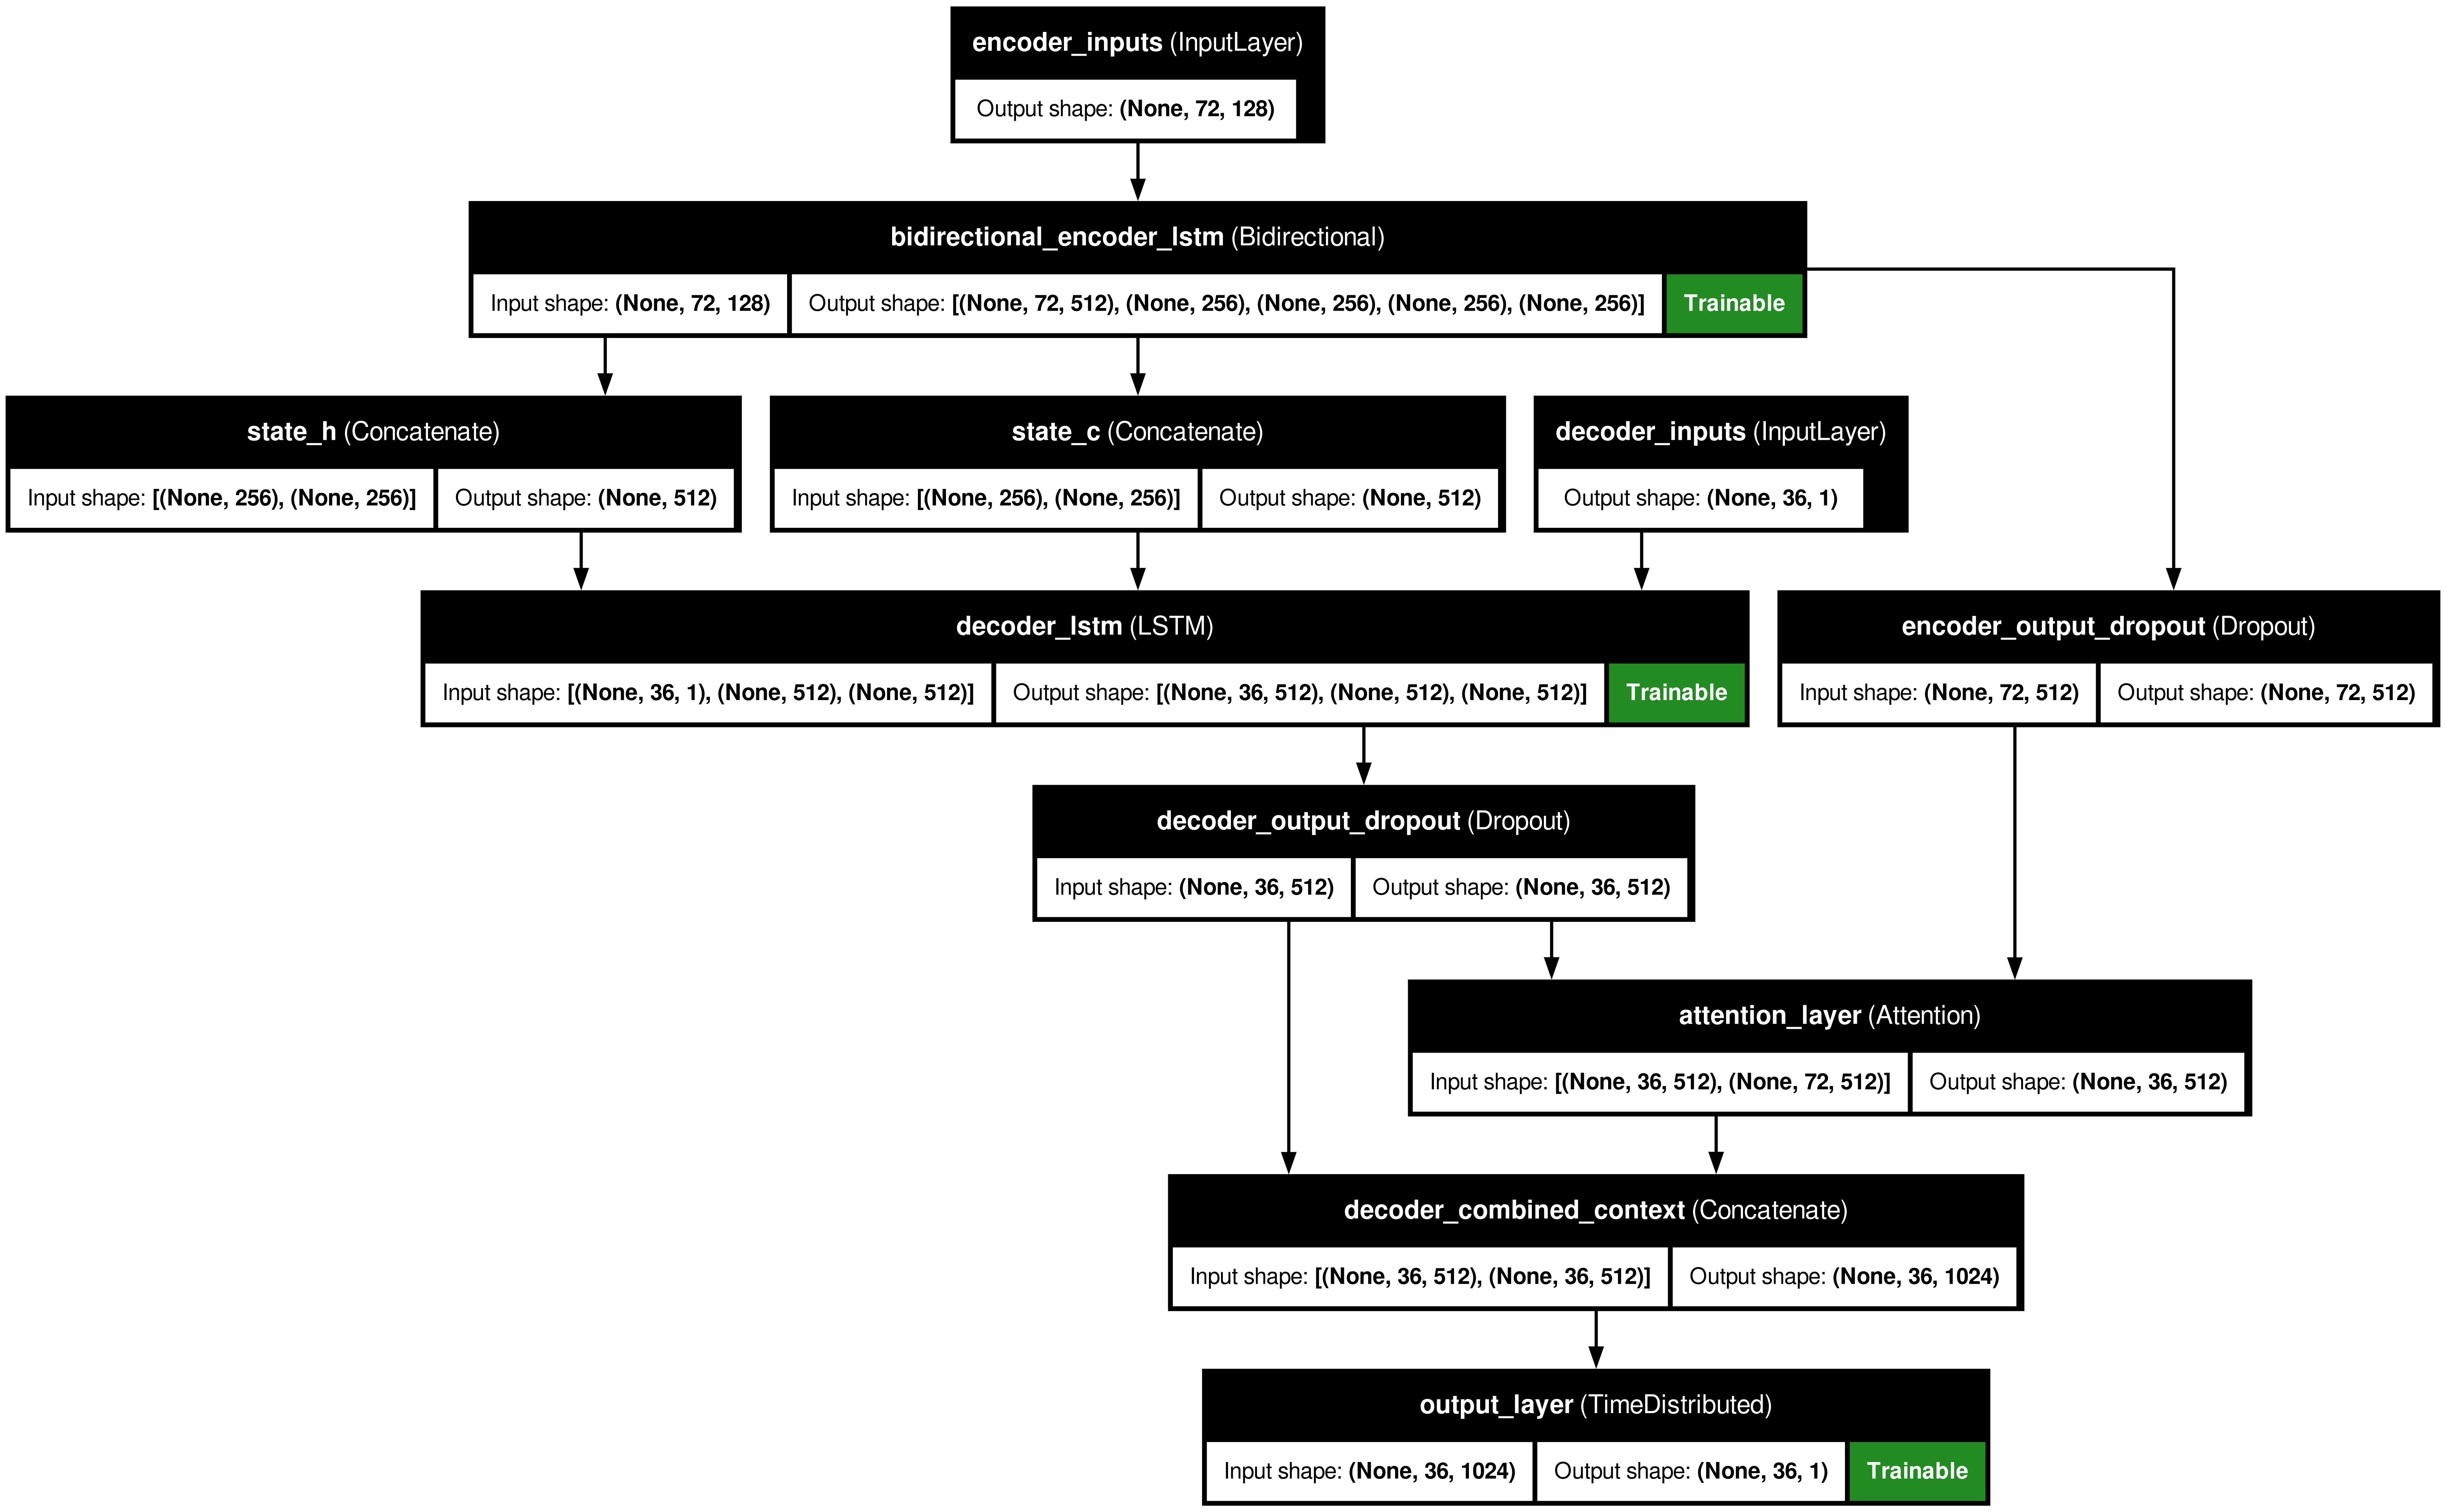

In [2]:
import sys
from pathlib import Path
from tensorflow.keras.utils import plot_model

import matplotlib.dates as mdates
import pandas as pd
import keras_tuner as kt

project_root = Path.cwd().resolve()
if not (project_root / "data" / "dataset.csv").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.s2s_lstm_bi_wrapper import S2SLSTMBidirectionalWrapper
from src.utils import wavelet_denoising

dataset = pd.read_csv(project_root / "data" / "dataset.csv")
dataset["id"] = pd.to_datetime(dataset["id"], format="mixed")
dataset = dataset.sort_values("id").set_index("id")

train_ratio = 0.75
val_ratio = 0.20

train_end = int(len(dataset) * train_ratio)
val_end = train_end + int(len(dataset) * val_ratio)

train_df = dataset.iloc[:train_end].copy()
val_df = dataset.iloc[train_end:val_end].copy()
test_df = dataset.iloc[val_end:].copy()

input_steps = 72
output_steps = 36

wrapper = S2SLSTMBidirectionalWrapper().prepare(
    train_df,
    val_df,
    input_steps=input_steps,
    output_steps=output_steps,
    target_col="ws100_wavelet",
    denoise=["ws100"],
)


hp = kt.HyperParameters()
model = wrapper.build(hp)
plot_model(wrapper.model, to_file='model_structure.png', show_trainable=True, show_shapes=True, show_layer_names=True, expand_nested=True, dpi=300)
#callbacks = [
#    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
#    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
#    ModelCheckpoint('../models/best_model.h5.keras', monitor='val_loss', save_best_only=True)
#]
#history = wrapper.fit(epochs=100, batch_size=32, verbose=1, callbacks=callbacks, use_validation=True)

#print("Rows:", len(dataset))
#print("Train/val/test:", len(train_df), len(val_df), len(test_df))
#print("Final training loss:", history.history["loss"][-1])

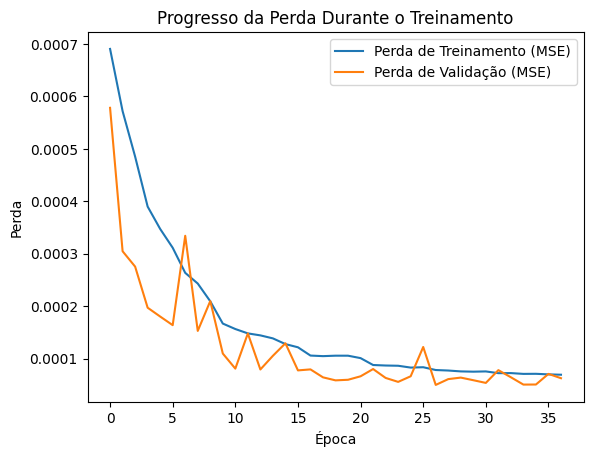

In [3]:

plt.plot(history.history['loss'][5:], label='Perda de Treinamento (MSE)')
plt.plot(history.history['val_loss'][5:], label='Perda de Validação (MSE)') #pula o primeiro pois a tcn tem perda alta na primeira época
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.title('Progresso da Perda Durante o Treinamento')
plt.savefig('../images/training_loss.png', dpi=300)
plt.show()

In [12]:
forecast_df = dataset.copy()
predictions, actuals = wrapper.rolling_forecast(forecast_df, test_start=val_end)

Starting rolling forecast from index 7182 to 7526


In [13]:
forecast_index = forecast_df.index[val_end + output_steps : val_end + output_steps - 1 + len(actuals)]
predictions = predictions.reshape(-1)[1:]
actuals = actuals.reshape(-1)

Predictions shape: (343,)
                            expected  predicted  old_predictions
id                                                              
2021-11-06 05:29:59.999997  7.049589   6.989193         7.545625
2021-11-06 05:40:00.000001  6.976737   6.917853         7.015099
2021-11-06 05:49:59.999996  6.912985   6.853825         6.976718
2021-11-06 06:00:00.000000  6.870333   6.811873         6.936406
2021-11-06 06:10:00.000004  6.812312   6.752827         6.911392


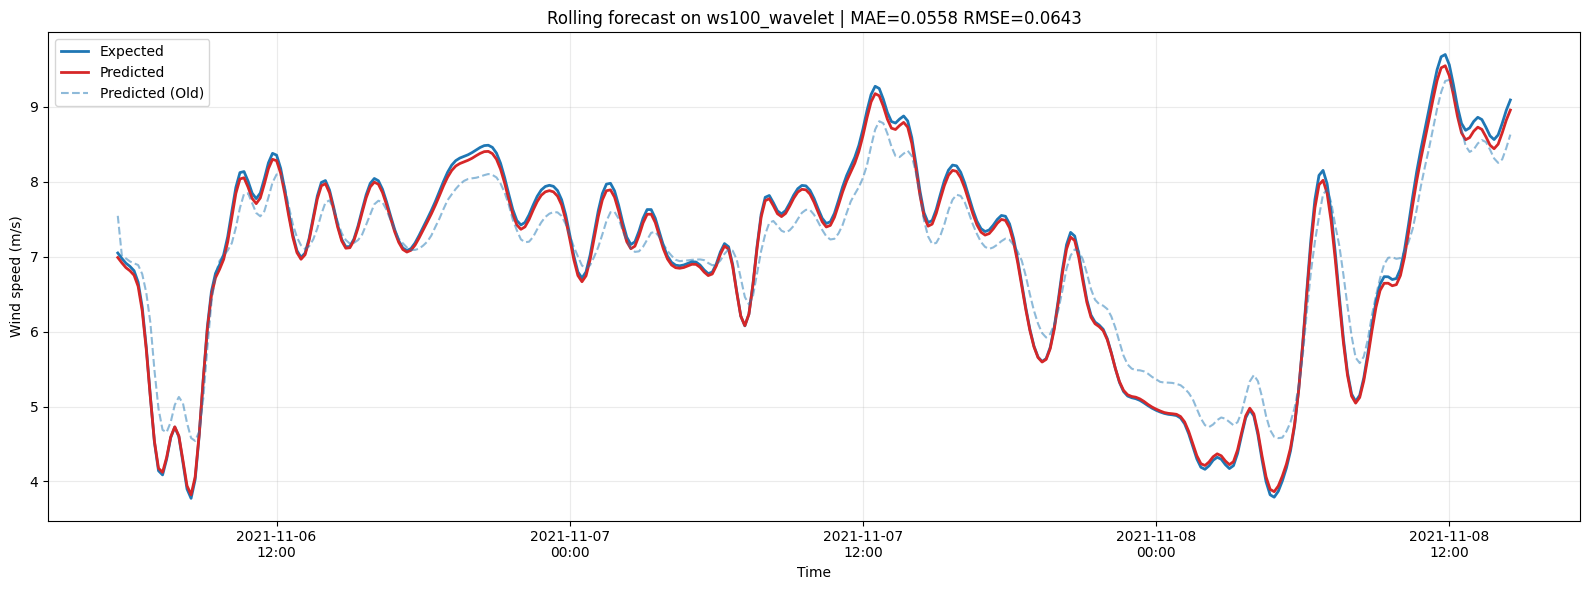

In [18]:
print(f"Predictions shape: {predictions.shape}")
old_predictions_df = pd.read_csv(project_root / "data" / "old_prediction.csv")
old_predictions = old_predictions_df['predictions'].values
old_predictions = old_predictions.reshape(-1)
#print(f"Old predictions shape: {old_predictions_df.shape}")
#print(old_predictions_df.head())
#print(predictions.head())


mae = mean_absolute_error(actuals[:-1], predictions)
rmse = np.sqrt(mean_squared_error(actuals[:-1], predictions))

results = pd.DataFrame(
    {
        "expected": actuals[:-1],
        "predicted": predictions,
        "old_predictions": old_predictions[:len(predictions)]
    },
    index=forecast_index,
)

print(results.head())

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(forecast_index, actuals[:-1], label="Expected", color="#1f77b4", linewidth=2)
ax.plot(forecast_index, predictions, label="Predicted", color="#d62728", linewidth=2)
ax.plot(forecast_index, old_predictions[:len(predictions)], label="Predicted (Old)", color="#1f77b4", linestyle='dashed', alpha=0.5)
ax.set_title(f"Rolling forecast on ws100_wavelet | MAE={mae:.4f} RMSE={rmse:.4f}")
ax.set_xlabel("Time")
ax.set_ylabel("Wind speed (m/s)")
ax.grid(alpha=0.25)
ax.legend()
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
plt.tight_layout()
plt.show()